In [15]:
import torch   
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

with_cuda = torch.cuda.is_available()
if with_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import os
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split, DataLoader, Dataset
from torch.amp import GradScaler
from torch.amp import autocast
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [16]:
def mp3_to_spec(path):
    try: 
        audio, sr = librosa.load(f"{path}", sr=22050)
        n_fft = 1024  
        hop_length = 512  
        
        stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
        spectrogram = np.abs(stft)
        log_spectrogram = librosa.amplitude_to_db(spectrogram)
    except Exception as e:
        print(f"[attention] Erreur sur {path} : {e}")
        return None, None
    return log_spectrogram

path_mp3 = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\recordings"
path_spec = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_test_non_pad"
for fichier in os.listdir(path_mp3):
        if fichier.endswith(".wav"):  # Vérifier si le fichier est un fichier .mp3
            fichier_mp3 = os.path.join(path_mp3, fichier) 
            fichier_spec = os.path.join(path_spec, f"{os.path.splitext(fichier)[0]}.npy")
            # Convertir le fichier mp3 en spectrogramme
            log_spectrogram = mp3_to_spec(fichier_mp3)
            # Sauvegarder le spectrogramme en tant que fichier .npy
            np.save(fichier_spec, log_spectrogram)

In [17]:
maxi= 0 
for fichier in os.listdir(path_spec):
        if fichier.endswith('.npy'):
            # Charger le spectrogramme
            spec_path = os.path.join(path_spec, fichier)
            spec = np.load(spec_path)
            if maxi < spec.shape[1]:
                maxi = spec.shape[1]
                print(spec.shape)
print(maxi)

(513, 13)
(513, 26)
(513, 33)
(513, 34)
(513, 43)
(513, 51)


KeyboardInterrupt: 

In [20]:
def pad_to_max(spec, target_width):
    # Créer un tableau de zéros de la taille cible
    normalized = np.zeros((spec.shape[0], target_width))
    
    # Si le spectrogramme est plus petit que la cible, on le remplit avec des zéros
    if spec.shape[1] < target_width:
        normalized[:, :spec.shape[1]] = spec
    # Si le spectrogramme est plus grand que la cible, on le tronque
    else:
        normalized = spec[:, :target_width]
    
    return normalized
        

In [21]:
path_spec_pad = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_test_pad"
for fichier in os.listdir(path_spec):
        if fichier.endswith('.npy'):
            # Charger le spectrogramme
            spec_path = os.path.join(path_spec, fichier)
            spec = np.load(spec_path)
            nouveau_spec = pad_to_max(spec, 50)
            # Sauvegarde dans le nouveau dossier
            path_out = os.path.join(path_spec_pad, fichier)
            np.save(path_out, nouveau_spec)

In [22]:
import IPython.display as ipd
def afficher_audio(spec):
    
    S = librosa.db_to_amplitude(spec)

    # 3. Reconstruction du signal audio via Griffin-Lim
    audio = librosa.griffinlim(S, hop_length=512, n_fft=1024)
    audio= librosa.effects.time_stretch(audio, rate=0.50)
    # 4. Lecture
    return ipd.Audio(audio, rate=22050)

Le spectrogramme avec la plus grande largeur est: 9_theo_16.npy
Sa largeur est de: 99


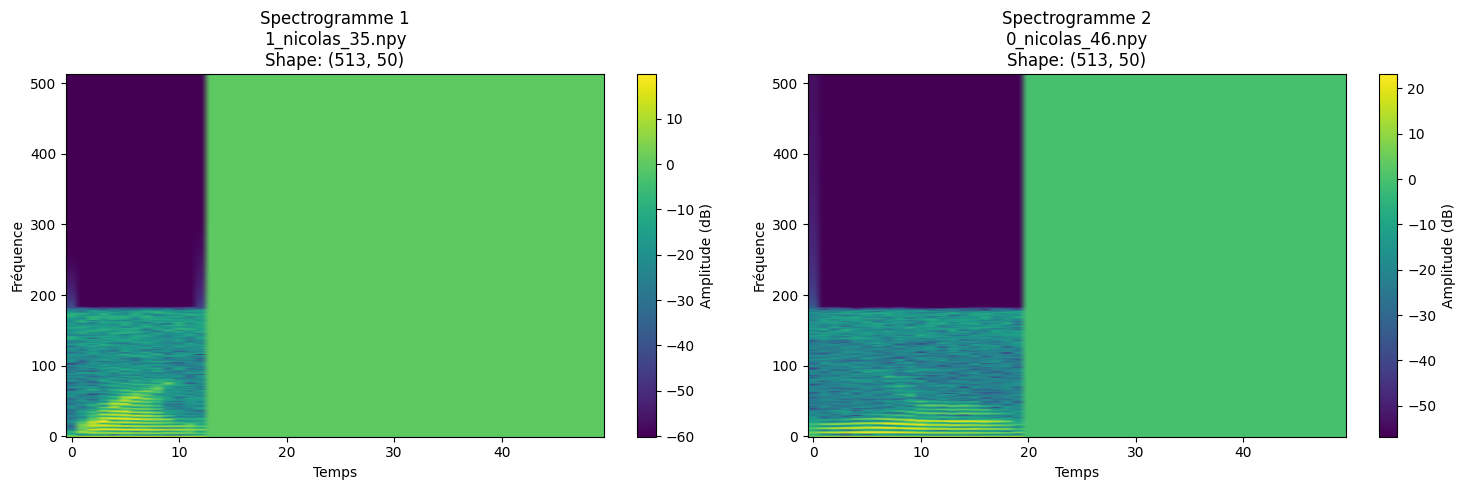

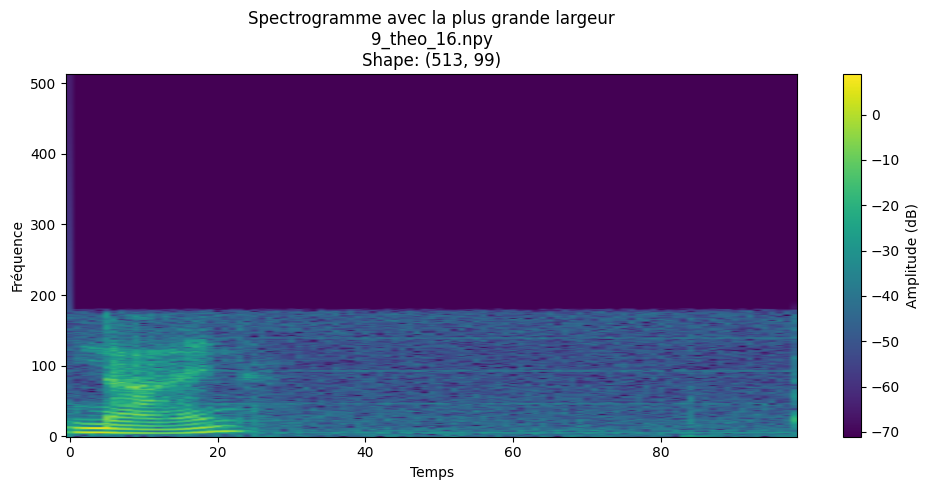

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Chemin vers le dossier des spectrogrammes
spec_path1 = Path("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_test_non_pad")
spec_path = Path("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\data_P3_P4\\P4\\spec_test_pad")

# Trouver le spectrogramme avec la plus grande largeur
max_width = 0
max_width_file = None

for file in spec_path1.glob('*.npy'):
    spec = np.load(file)
    if spec.shape[1] > max_width:
        max_width = spec.shape[1]
        max_width_file = file

print(f"Le spectrogramme avec la plus grande largeur est: {max_width_file.name}")
print(f"Sa largeur est de: {max_width}")

# Charger deux spectrogrammes aléatoires
spec_files = list(spec_path.glob('*.npy'))
spec1_file = np.random.choice(spec_files)
spec2_file = np.random.choice([f for f in spec_files if f != spec1_file])

spec1 = np.load(spec1_file)
spec2 = np.load(spec2_file)

# Créer une figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Afficher le premier spectrogramme
im1 = ax1.imshow(spec1, aspect='auto', origin='lower')
ax1.set_title(f'Spectrogramme 1\n{spec1_file.name}\nShape: {spec1.shape}')
ax1.set_xlabel('Temps')
ax1.set_ylabel('Fréquence')
plt.colorbar(im1, ax=ax1, label='Amplitude (dB)')

# Afficher le deuxième spectrogramme
im2 = ax2.imshow(spec2, aspect='auto', origin='lower')
ax2.set_title(f'Spectrogramme 2\n{spec2_file.name}\nShape: {spec2.shape}')
ax2.set_xlabel('Temps')
ax2.set_ylabel('Fréquence')
plt.colorbar(im2, ax=ax2, label='Amplitude (dB)')

plt.tight_layout()
plt.show()

# Afficher le spectrogramme avec la plus grande largeur
max_spec = np.load(max_width_file)

plt.figure(figsize=(10, 5))
im = plt.imshow(max_spec, aspect='auto', origin='lower')
plt.title(f'Spectrogramme avec la plus grande largeur\n{max_width_file.name}\nShape: {max_spec.shape}')
plt.xlabel('Temps')
plt.ylabel('Fréquence')
plt.colorbar(label='Amplitude (dB)')
plt.tight_layout()
plt.show()


In [24]:
afficher_audio(spec1)


In [29]:
afficher_audio(spec2)
